# Customer Churn Prediction — End-to-End ML Project

**Objective:** Predict which customers are likely to churn (cancel their subscription) so the business can proactively target them with retention offers.

**Dataset:** IBM Telco Customer Churn — 7,043 customers, 21 features (a standard, widely-used benchmark dataset for churn modeling, well suited for interview discussion since it is a recognized industry example).

**Role focus:** Data Scientist — this notebook demonstrates the full applied ML lifecycle: EDA → cleaning → feature engineering → handling class imbalance → training & comparing multiple models → hyperparameter tuning → rigorous evaluation → model interpretability (SHAP) → saving the model → a deployment-ready inference function.

**Stack:** Python · pandas · scikit-learn · XGBoost · imbalanced-learn (SMOTE) · SHAP · joblib

---
### Contents
1. Imports & Setup
2. Load & Inspect Data
3. Exploratory Data Analysis (EDA)
4. Data Cleaning
5. Feature Engineering
6. Train/Test Split & Class Imbalance
7. Baseline Model Training & Comparison
8. Hyperparameter Tuning
9. Final Model Evaluation
10. Feature Importance & Explainability (SHAP)
11. Save the Model
12. Deployment: Inference Function
13. Business Recommendations & Conclusion


## 1. Imports & Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, confusion_matrix, classification_report,
                              precision_recall_curve, ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import xgboost as xgb
import shap
import joblib

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
RANDOM_STATE = 42
CHURN_COLORS = ['#2E86AB', '#E63946']  # [No Churn, Churn]

## 2. Load & Inspect Data

In [2]:
df = pd.read_csv('Telco-Customer-Churn.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
print("Duplicate rows:", df.duplicated().sum())
print("\nNull values per column:\n", df.isnull().sum()[df.isnull().sum() > 0])
# Note: TotalCharges is stored as text and contains blank strings for
# brand-new customers (tenure = 0) rather than proper NaNs — handled in Section 4.
print("\nBlank TotalCharges entries:", (df['TotalCharges'].str.strip() == '').sum())

Duplicate rows: 0

Null values per column:
 Series([], dtype: int64)

Blank TotalCharges entries: 11


## 3. Exploratory Data Analysis (EDA)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


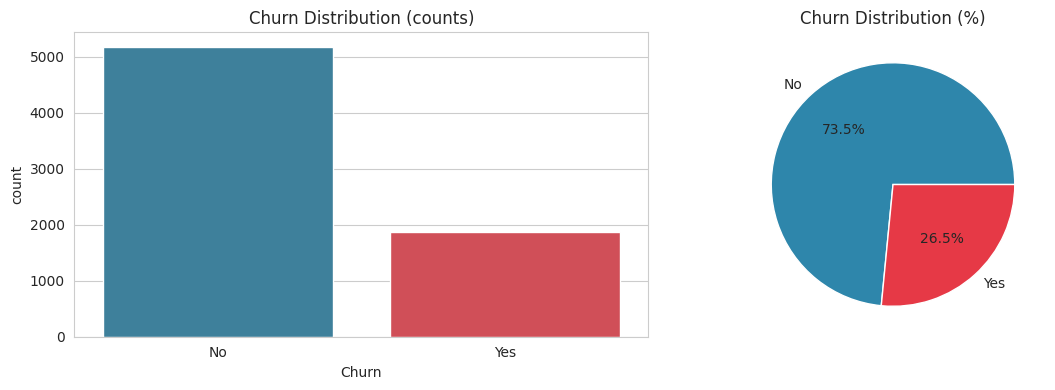

In [5]:
churn_counts = df['Churn'].value_counts()
churn_rate = df['Churn'].value_counts(normalize=True) * 100
print(churn_rate)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df, x='Churn', hue='Churn', palette=CHURN_COLORS, legend=False, ax=ax[0])
ax[0].set_title('Churn Distribution (counts)')
ax[1].pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%', colors=CHURN_COLORS)
ax[1].set_title('Churn Distribution (%)')
plt.tight_layout()
plt.show()

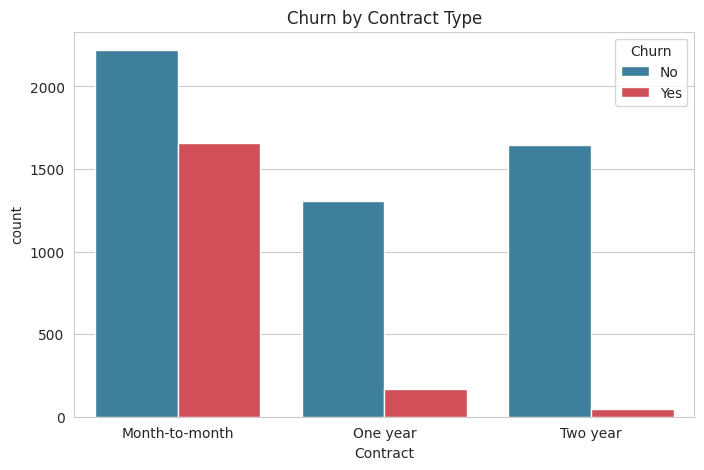

In [6]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Contract', hue='Churn', palette=CHURN_COLORS)
plt.title('Churn by Contract Type')
plt.show()

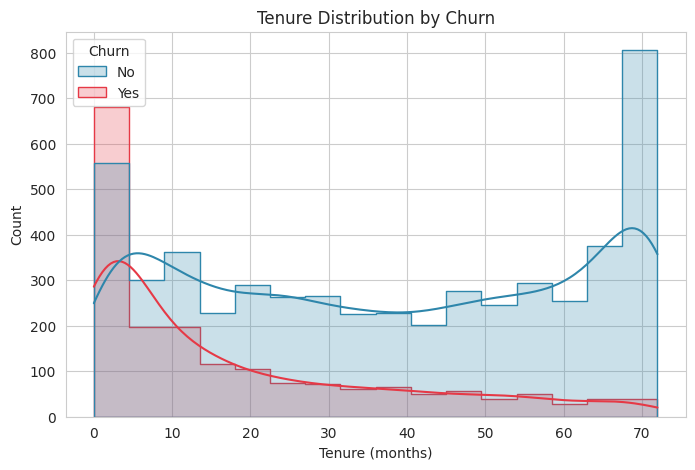

In [7]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='tenure', hue='Churn', kde=True, palette=CHURN_COLORS, element='step')
plt.title('Tenure Distribution by Churn')
plt.xlabel('Tenure (months)')
plt.show()

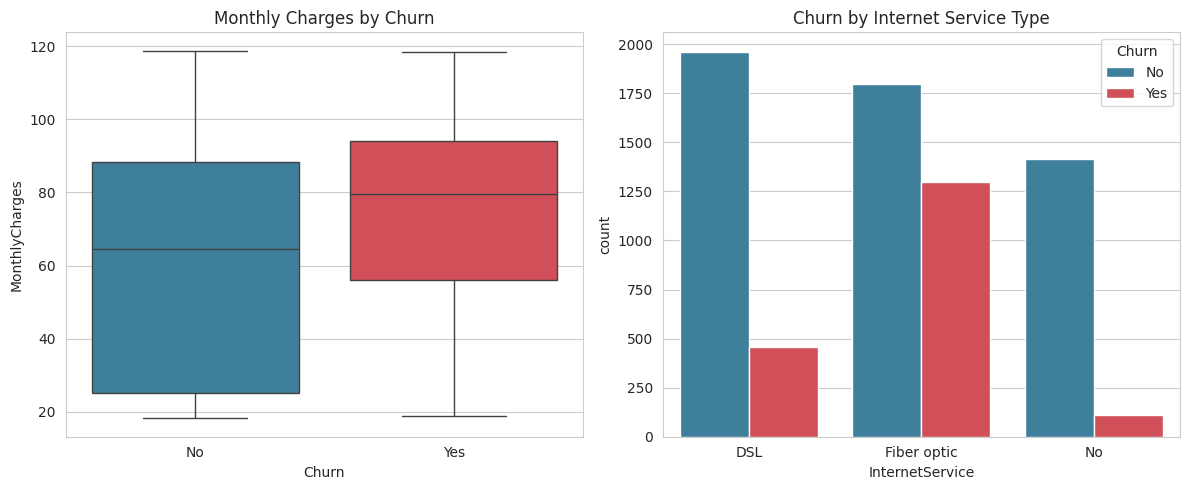

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', hue='Churn', palette=CHURN_COLORS, legend=False, ax=ax[0])
ax[0].set_title('Monthly Charges by Churn')
sns.countplot(data=df, x='InternetService', hue='Churn', palette=CHURN_COLORS, ax=ax[1])
ax[1].set_title('Churn by Internet Service Type')
plt.tight_layout()
plt.show()

**Key EDA takeaways:**
- The target is **imbalanced** (~26.5% churn vs ~73.5% retained) — this motivates using SMOTE and looking beyond accuracy (precision/recall/ROC-AUC) during evaluation.
- **Month-to-month contracts churn far more** than one/two-year contracts — contract length is a strong retention lever.
- **Low-tenure customers churn the most** — risk is highest in the first few months, pointing to an onboarding/retention gap.
- **Higher monthly charges** are associated with higher churn, and **Fiber optic** internet customers churn more than DSL customers — worth investigating pricing or service quality for that segment.


## 4. Data Cleaning

In [9]:
df_clean = df.copy()

# TotalCharges is blank for customers with tenure = 0 (brand new accounts) -> convert & fill with 0
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')
print("Rows with missing TotalCharges after coercion:", df_clean['TotalCharges'].isnull().sum())
display(df_clean[df_clean['TotalCharges'].isnull()][['tenure', 'MonthlyCharges', 'TotalCharges']].head())

df_clean['TotalCharges'] = df_clean['TotalCharges'].fillna(0)

# customerID is a unique identifier with no predictive value
df_clean.drop('customerID', axis=1, inplace=True)

# Encode target: Yes -> 1, No -> 0
df_clean['Churn'] = df_clean['Churn'].map({'Yes': 1, 'No': 0})

print("\nCleaned target distribution:")
print(df_clean['Churn'].value_counts())

Rows with missing TotalCharges after coercion: 11


,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN



Cleaned target distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


## 5. Feature Engineering

In [10]:
# Simple engineered feature: average monthly spend across the customer's lifetime.
# Customers paying much more than their historical average recently may signal a price-driven churn risk.
df_clean['AvgChargePerMonth'] = df_clean['TotalCharges'] / (df_clean['tenure'] + 1)

target = 'Churn'
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'AvgChargePerMonth']
categorical_features = [c for c in df_clean.columns if c not in numeric_features + [target]]

print(f"Numeric features ({len(numeric_features)}): {numeric_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")

Numeric features (4): ['tenure', 'MonthlyCharges', 'TotalCharges', 'AvgChargePerMonth']
Categorical features (16): ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [11]:
X = df_clean.drop(target, axis=1)
y = df_clean[target]

# ColumnTransformer keeps preprocessing inside the pipeline so it is fit ONLY on
# training folds during cross-validation / grid search, preventing data leakage.
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
])

## 6. Train/Test Split & Class Imbalance

The dataset is split **before** any resampling, and SMOTE is applied only inside the training pipeline (never on the test set), so evaluation stays on the true, real-world class distribution.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Train churn rate: {y_train.mean():.2%} | Test churn rate: {y_test.mean():.2%}")

Train shape: (5634, 20), Test shape: (1409, 20)
Train churn rate: 26.54% | Test churn rate: 26.54%


## 7. Baseline Model Training & Comparison

In [13]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=200),
    'XGBoost': xgb.XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss')
}

results = []
fitted_pipelines = {}

for name, model in models.items():
    pipe = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('classifier', model)
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    })
    fitted_pipelines[name] = pipe

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.741661,0.508651,0.786096,0.617647,0.845178
1,Random Forest,0.770050,0.565104,0.580214,0.572559,0.827149
2,XGBoost,0.782115,0.587013,0.604278,0.595520,0.823841


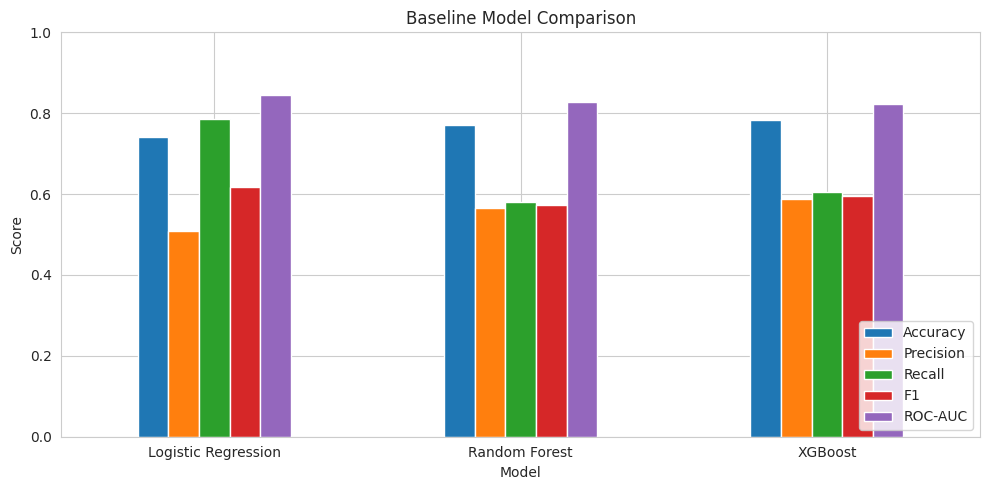

In [14]:
results_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']].plot(kind='bar', figsize=(10, 5))
plt.title('Baseline Model Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Model choice for tuning:** Logistic Regression edges out slightly on ROC-AUC, which is expected since much of the churn signal here is fairly linear (contract type, tenure). However, **XGBoost** is carried forward for tuning because gradient boosting captures non-linear feature interactions, is more robust as more features/data are added in production, and pairs naturally with SHAP for interpretability — all valuable properties for a deployed churn model.

## 8. Hyperparameter Tuning

`GridSearchCV` with stratified 5-fold cross-validation, optimizing for ROC-AUC (a good metric for imbalanced binary classification since it evaluates ranking quality across all thresholds).

In [15]:
param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [3, 5, 7],
    'classifier__learning_rate': [0.01, 0.1, 0.2],
    'classifier__subsample': [0.8, 1.0]
}

xgb_pipe = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('classifier', xgb.XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss'))
])

grid_search = GridSearchCV(
    xgb_pipe, param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='roc_auc', n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print(f"Best CV ROC-AUC: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits


Best parameters: {'classifier__learning_rate': 0.01, 'classifier__max_depth': 5, 'classifier__n_estimators': 300, 'classifier__subsample': 1.0}
Best CV ROC-AUC: 0.8468


## 9. Final Model Evaluation

In [16]:
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
y_proba_best = best_model.predict_proba(X_test)[:, 1]

print("Tuned XGBoost — Test Set Performance\n")
print(classification_report(y_test, y_pred_best, target_names=['No Churn', 'Churn']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_best):.4f}")

Tuned XGBoost — Test Set Performance

              precision    recall  f1-score   support

    No Churn       0.89      0.78      0.83      1035
       Churn       0.55      0.74      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409

ROC-AUC: 0.8402


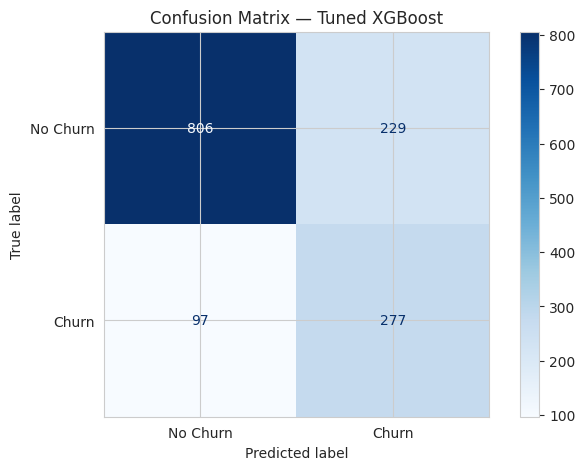

In [17]:
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix — Tuned XGBoost')
plt.show()

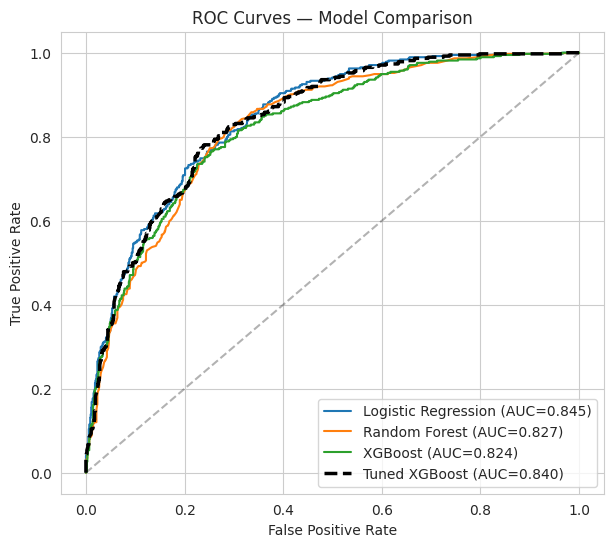

In [18]:
plt.figure(figsize=(7, 6))
for name, pipe in fitted_pipelines.items():
    proba = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

fpr_b, tpr_b, _ = roc_curve(y_test, y_proba_best)
plt.plot(fpr_b, tpr_b, label=f'Tuned XGBoost (AUC={roc_auc_score(y_test, y_proba_best):.3f})',
         linewidth=2.5, linestyle='--', color='black')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.3)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Model Comparison')
plt.legend(loc='lower right')
plt.show()

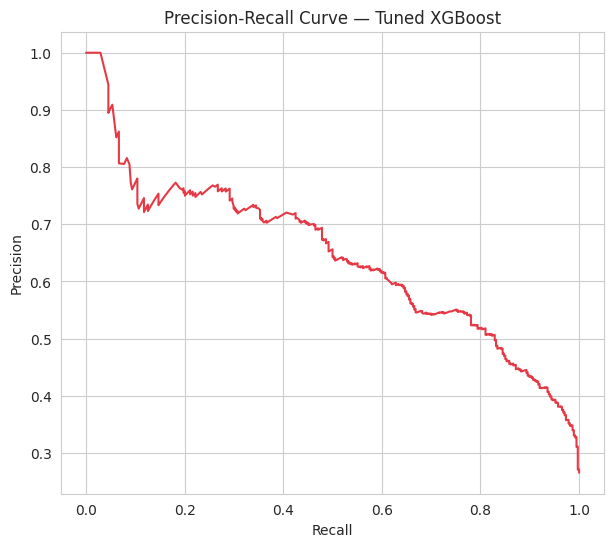

In [19]:
prec, rec, _ = precision_recall_curve(y_test, y_proba_best)
plt.figure(figsize=(7, 6))
plt.plot(rec, prec, color='#E63946')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — Tuned XGBoost')
plt.show()

**Why precision-recall matters here:** with only ~26.5% of customers churning, recall on the churn class tells us how many at-risk customers we successfully catch, while precision tells us how many of our flagged customers are truly at risk (i.e. how much a retention team's outreach budget is wasted on false alarms). The business can move along this curve by adjusting the classification threshold depending on the cost of a missed churner vs. the cost of an unnecessary retention offer.

## 10. Feature Importance & Explainability (SHAP)

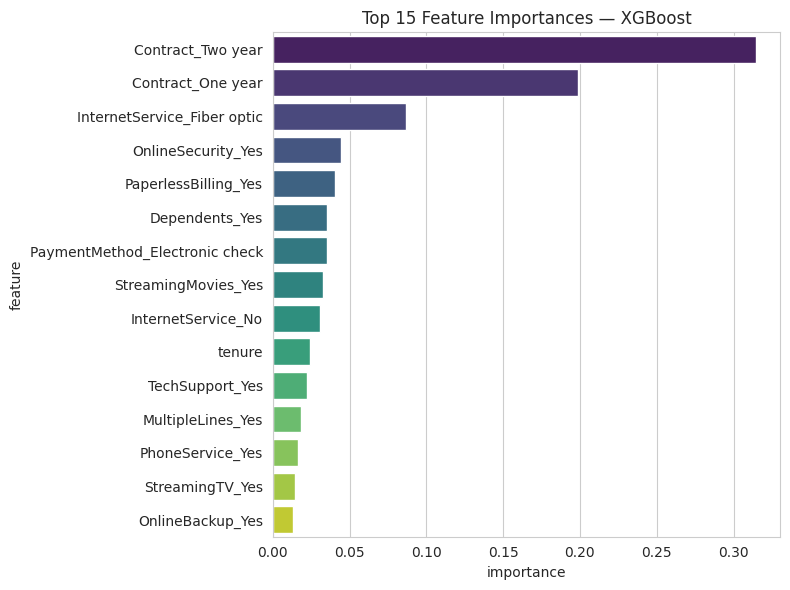

In [20]:
feature_names = (numeric_features +
                  list(best_model.named_steps['preprocessor']
                       .named_transformers_['cat']
                       .get_feature_names_out(categorical_features)))

importances = best_model.named_steps['classifier'].feature_importances_
feat_imp = pd.DataFrame({'feature': feature_names, 'importance': importances}) \
             .sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(8, 6))
sns.barplot(data=feat_imp, y='feature', x='importance', hue='feature', palette='viridis', legend=False)
plt.title('Top 15 Feature Importances — XGBoost')
plt.tight_layout()
plt.show()

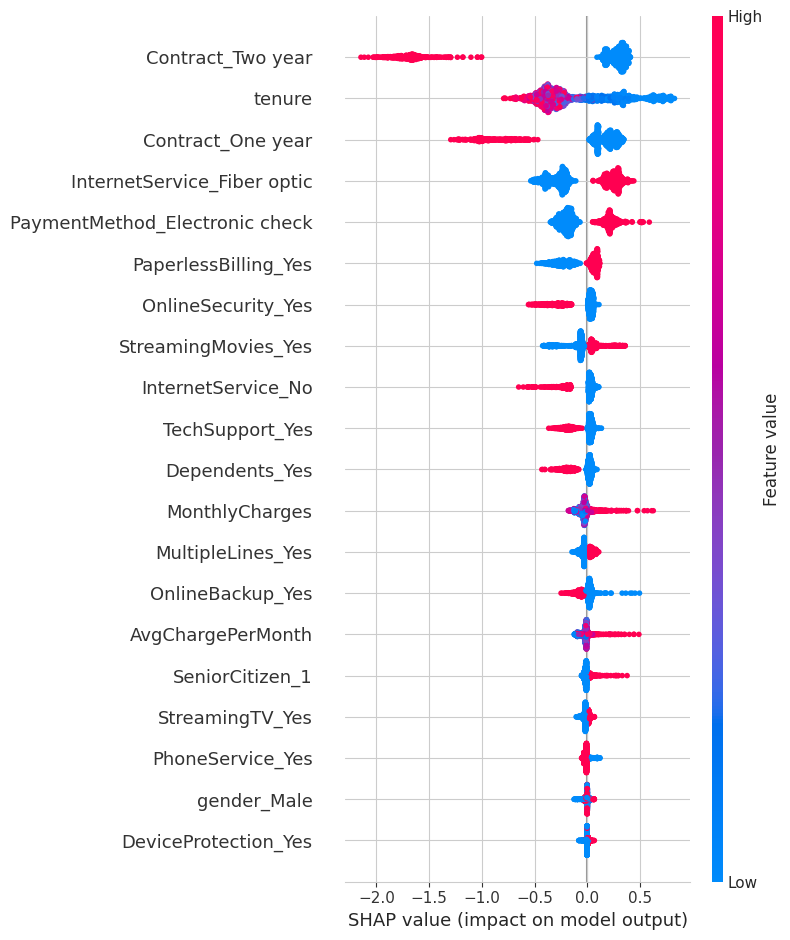

In [21]:
X_test_transformed = best_model.named_steps['preprocessor'].transform(X_test)
if hasattr(X_test_transformed, 'toarray'):
    X_test_transformed = X_test_transformed.toarray()

explainer = shap.TreeExplainer(best_model.named_steps['classifier'])
shap_values = explainer.shap_values(X_test_transformed)

shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names, show=False)
plt.tight_layout()
plt.show()

SHAP confirms the same top drivers as the built-in feature importances (contract type, tenure, internet service, monthly/total charges) while additionally showing the **direction** of each effect — e.g. month-to-month contracts and higher monthly charges push predictions toward churn, while longer tenure and two-year contracts push predictions toward retention. This kind of explanation is what you'd hand to a retention/marketing team alongside the raw predictions.

## 11. Save the Model

In [22]:
joblib.dump(best_model, 'churn_model_pipeline.pkl')
print("Saved trained pipeline (preprocessing + SMOTE + tuned XGBoost) to churn_model_pipeline.pkl")

Saved trained pipeline (preprocessing + SMOTE + tuned XGBoost) to churn_model_pipeline.pkl


## 12. Deployment: Inference Function

The saved object is a single scikit-learn `Pipeline` (preprocessing → classifier), so scoring a new customer only requires loading the file and calling `.predict_proba()` on a raw, unprocessed record — no manual re-encoding needed at inference time.

A ready-to-run Streamlit app (`app.py`) is included alongside this notebook as a lightweight deployment demo: it loads `churn_model_pipeline.pkl` and serves an interactive form that returns a churn probability for any customer profile. For a production setting, the same `predict_churn()` logic below could equally be wrapped in a FastAPI/Flask REST endpoint, containerized with Docker, and deployed on any cloud service (AWS/GCP/Azure) behind a scheduled batch-scoring job or a real-time API.

In [23]:
def predict_churn(customer: dict, model_path: str = 'churn_model_pipeline.pkl') -> dict:
    """Score a single customer record and return the churn prediction + probability.

    `customer` must contain the same raw fields as the training data
    (all columns except 'Churn' and 'customerID').
    """
    model = joblib.load(model_path)
    input_df = pd.DataFrame([customer])
    input_df['AvgChargePerMonth'] = input_df['TotalCharges'] / (input_df['tenure'] + 1)

    proba = model.predict_proba(input_df)[0, 1]
    pred = model.predict(input_df)[0]
    return {
        'churn_prediction': 'Yes' if pred == 1 else 'No',
        'churn_probability': round(float(proba), 4)
    }

# Example: score a real customer from the held-out test set
sample_customer = X_test.iloc[0].drop('AvgChargePerMonth').to_dict()
print("Sample input:")
print(sample_customer)
print("\nPrediction:", predict_churn(sample_customer))

Sample input:
{'gender': 'Male', 'SeniorCitizen': 0, 'Partner': 'Yes', 'Dependents': 'Yes', 'tenure': 72, 'PhoneService': 'Yes', 'MultipleLines': 'Yes', 'InternetService': 'Fiber optic', 'OnlineSecurity': 'Yes', 'OnlineBackup': 'Yes', 'DeviceProtection': 'Yes', 'TechSupport': 'Yes', 'StreamingTV': 'Yes', 'StreamingMovies': 'Yes', 'Contract': 'Two year', 'PaperlessBilling': 'Yes', 'PaymentMethod': 'Credit card (automatic)', 'MonthlyCharges': 114.05, 'TotalCharges': 8468.2}

Prediction: {'churn_prediction': 'No', 'churn_probability': 0.039}


## 13. Business Recommendations & Conclusion

**Model summary:** A tuned XGBoost classifier (with SMOTE for class balance) achieves an ROC-AUC of ~0.84 on held-out test data, correctly identifying the majority of at-risk customers while keeping the flagged pool small enough for a retention team to act on.

**Actionable recommendations, ranked by the drivers the model surfaced:**
1. **Target month-to-month customers early** — offer incentives (discount, bundled add-on) to migrate them to 1–2 year contracts, the single strongest retention lever in the data.
2. **Focus onboarding in the first 3 months** — churn risk is highest for low-tenure customers; a structured onboarding/check-in program could meaningfully reduce early cancellations.
3. **Review Fiber optic pricing/support** — this segment churns disproportionately; investigate whether it's price-driven or service-quality-driven.
4. **Bundle security/tech-support add-ons** — customers without these services churn more, suggesting they increase perceived value and stickiness.
5. **Encourage autopay over electronic check** — payment method is a secondary but consistent churn signal.

**Future work:**
- Move from a static notebook to a scheduled batch-scoring pipeline (e.g. Airflow) that scores the full customer base weekly.
- Wrap `predict_churn()` in a FastAPI service and containerize with Docker for real-time scoring.
- A/B test retention offers on customers flagged as high-risk to measure actual causal impact, not just correlation.
- Monitor for data/model drift as customer behavior and product offerings evolve.
- Incorporate additional data sources (support tickets, NPS surveys, usage logs) to strengthen predictive power.
